3rd Test - Cane segmentation - Image 2750 - 512x512


In [40]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [41]:
# Check shape
print(hsv_img.shape) # Result: (1080, 1920, 3)

(1080, 1920, 3)


In [42]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [43]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
1st Test
Writing down values (Hue, Saturation, Value)
lower_bound = [32, 84, 176]
upper_bound = [60, 156, 187]
"""

"""
2nd Test
Writing down values (Hue, Saturation, Value)
lower_bound = [35, 77, 163]
upper_bound = [72, 163, 214]
"""

'\n2nd Test\nWriting down values (Hue, Saturation, Value)\nlower_bound = [35, 77, 163]\nupper_bound = [72, 163, 214]\n'

Image Before Resize: (1080, 1920)


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

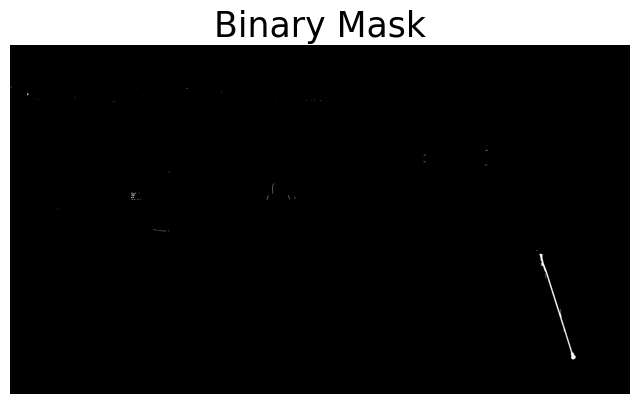

In [53]:
### Process ###
# First Step - Limits
# 1 - Define Cane color limits >> HSV (H:32, S:84, V:176) to (H:60, S:156, V:187)
# New values ​​considering preprocessing
lower_bound = np.array([35, 77, 163]) # Hue, Saturation, Value
upper_bound = np.array([72, 163, 214]) # Hue, Saturation, Value

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)
print('Image Before Resize:', mask.shape)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [45]:
# 2.4 - Check Mask Values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Values are 0 and 255.
"""

'\nValues are 0 and 255.\n'

Image After Resize: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

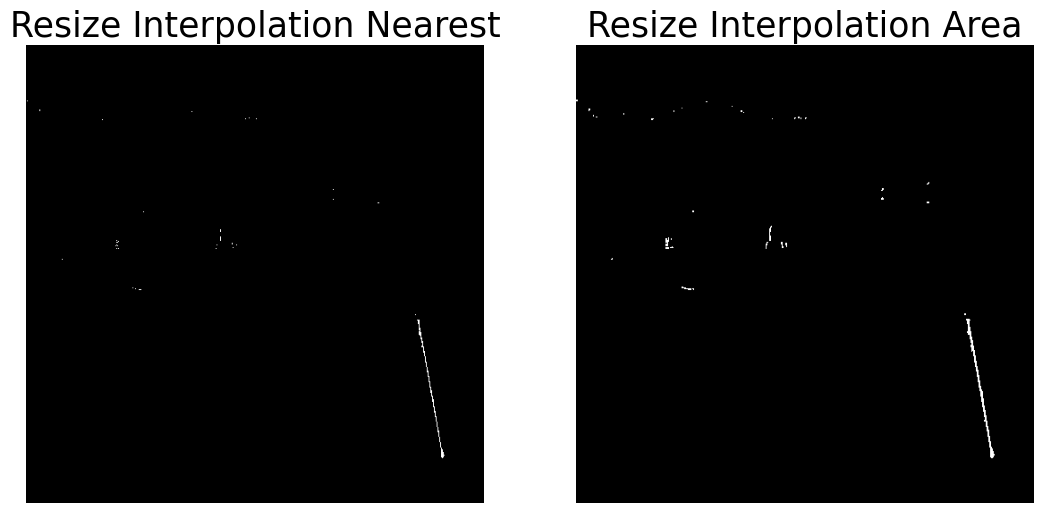

In [54]:
# Test: Resize mask and image
mask1 = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)
mask2 = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)
# Re-Binarize
mask1 = np.where(mask1 > 0, 255, 0).astype(np.uint8) # less noise
mask2 = np.where(mask2 > 0, 255, 0).astype(np.uint8) # more noise
print('Image After Resize:', mask2.shape)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(mask1, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
# # Test 2: Resize mask and image
# mask1 = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)
# mask2 = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)
# # Re-Binarize with new threshold over 127 (Better Result)
# mask1 = np.where(mask1 > 127, 255, 0).astype(np.uint8)
# mask2 = np.where(mask2 > 127, 255, 0).astype(np.uint8)
# print('Image After Resize:', mask2.shape)

# # Setup Plot
# plt.figure(figsize=[13,13])
# # Plotting original image
# plt.subplot(121)
# plt.imshow(mask1, cmap='gray')
# plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
# plt.axis('off')
# # Plotting binary mask
# plt.subplot(122)
# plt.imshow(mask2, cmap='gray')
# plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
# plt.axis('off')

In [55]:
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Image", mask)

cv.imshow("Inspect Image", mask1) # Mask 1 (512x512 - Nearest)
# cv.imshow("Inspect Image", mask2)   # Mask 2 (512x512 - Area)

cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

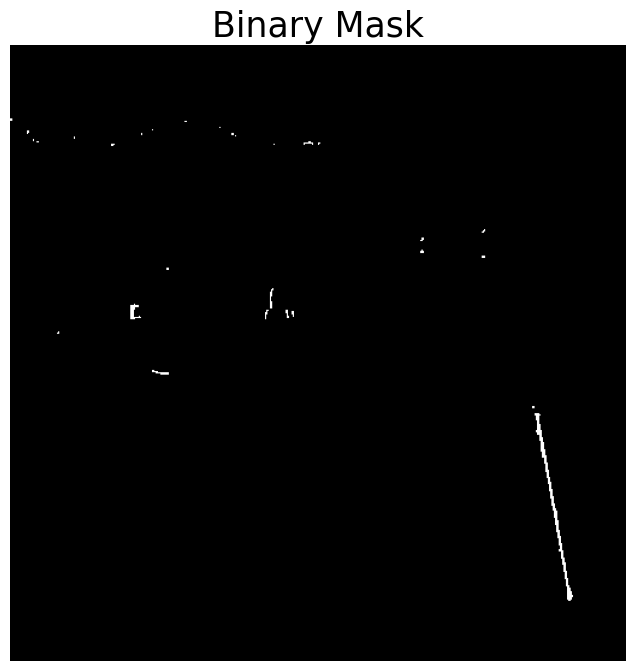

In [62]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask2, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask2, cv.MORPH_CLOSE, kernel) # Close small holes


plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
# 3.5 - Check Mask values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

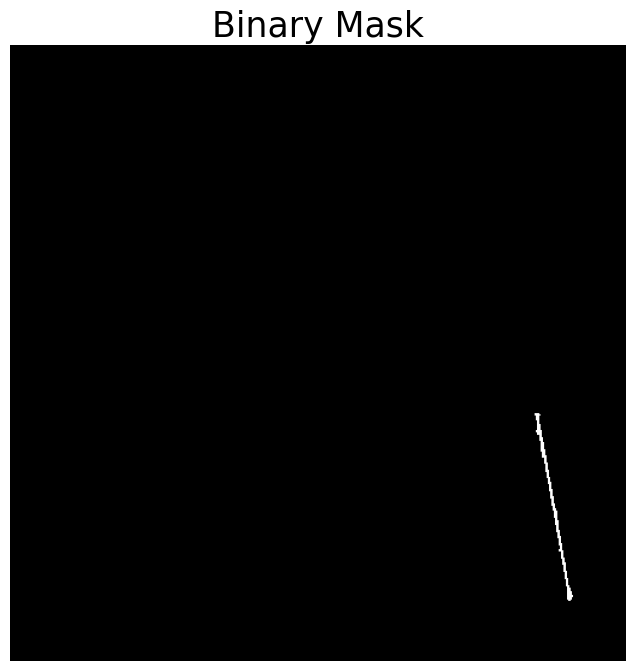

In [ ]:
# Third Step - Remove Noise
# 3.1 - Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 50 # change from 10 (1920x1080) to 50 (512x512)

# 3.2 - Filter
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        cv.drawContours(filtered_mask, [contour], -1, (255), -1)

# 3.3 - Reassign mask with the filtered mask
mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

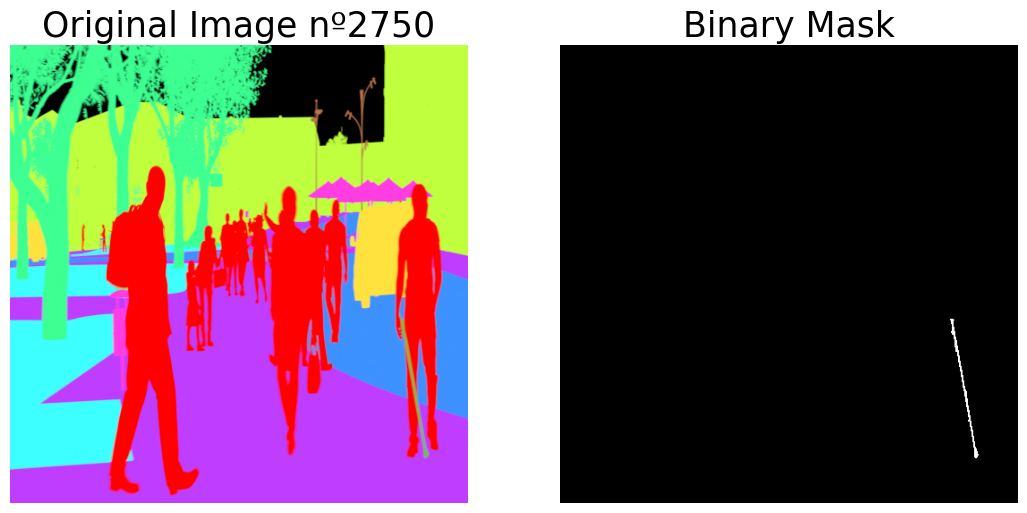

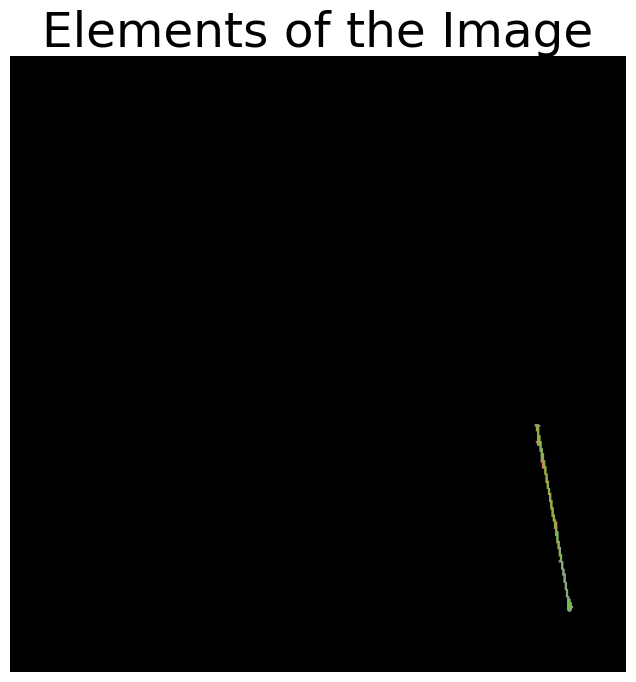

In [68]:
# Visualize Segmentation
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

4th Test - Cane Segmentation - Image 2635 - 512x512 (Work in Progress)

In [ ]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value)
lower_bound = [35, 77, 163]
upper_bound = [72, 163, 214]
"""

In [ ]:
### Process ###
# First Step - Limits
# 1 - Define Cane color limits >> HSV (H:35, S:77, V:163) to (H:72, S:163, V:214)
# New values ​​considering preprocessing
lower_bound = np.array([35, 77, 163]) # Hue, Saturation, Value
upper_bound = np.array([72, 163, 214]) # Hue, Saturation, Value

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", mask)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", mask)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
# Third Step - Remove Noise
# 3.1 - Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 10 # manual fine tuning

# 3.2 - Filter
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        cv.drawContours(filtered_mask, [contour], -1, (255), -1)

# 3.3 - Reassign mask with the filtered mask
mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [ ]:
# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')